In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet18, resnet34, resnet50
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
path = "/kaggle/input/competitions/neoai-2025-cuties-segmentation/cuties"
os.listdir(path)

['test_imgs', 'val_imgs', 'val_masks']

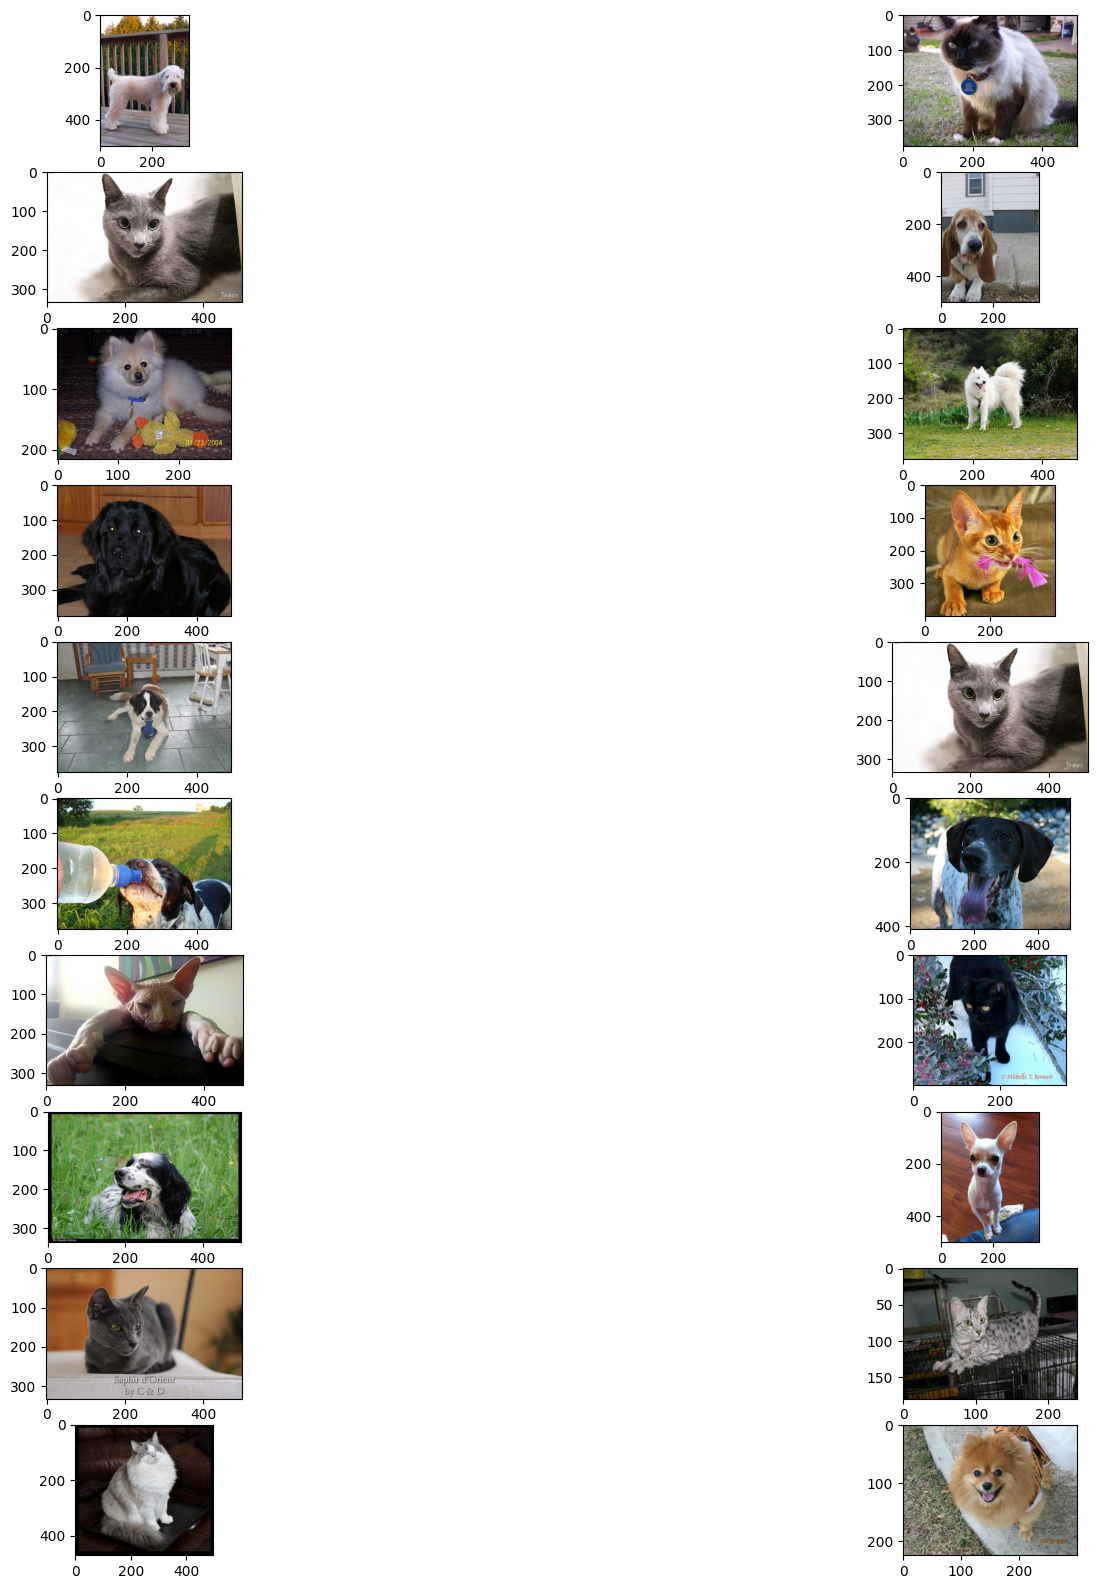

In [3]:
fig, axes= plt.subplots(10, 2, figsize= (20, 20))
axes  = axes.flatten()
train_img_path = os.path.join(path, "val_imgs")
train_mask_path = os.path.join(path, "val_masks")
for idx, file in enumerate(os.listdir(train_img_path)):
    img= Image.open(os.path.join(train_img_path, file)).convert("RGB")
    axes[idx].imshow(img)
plt.show()

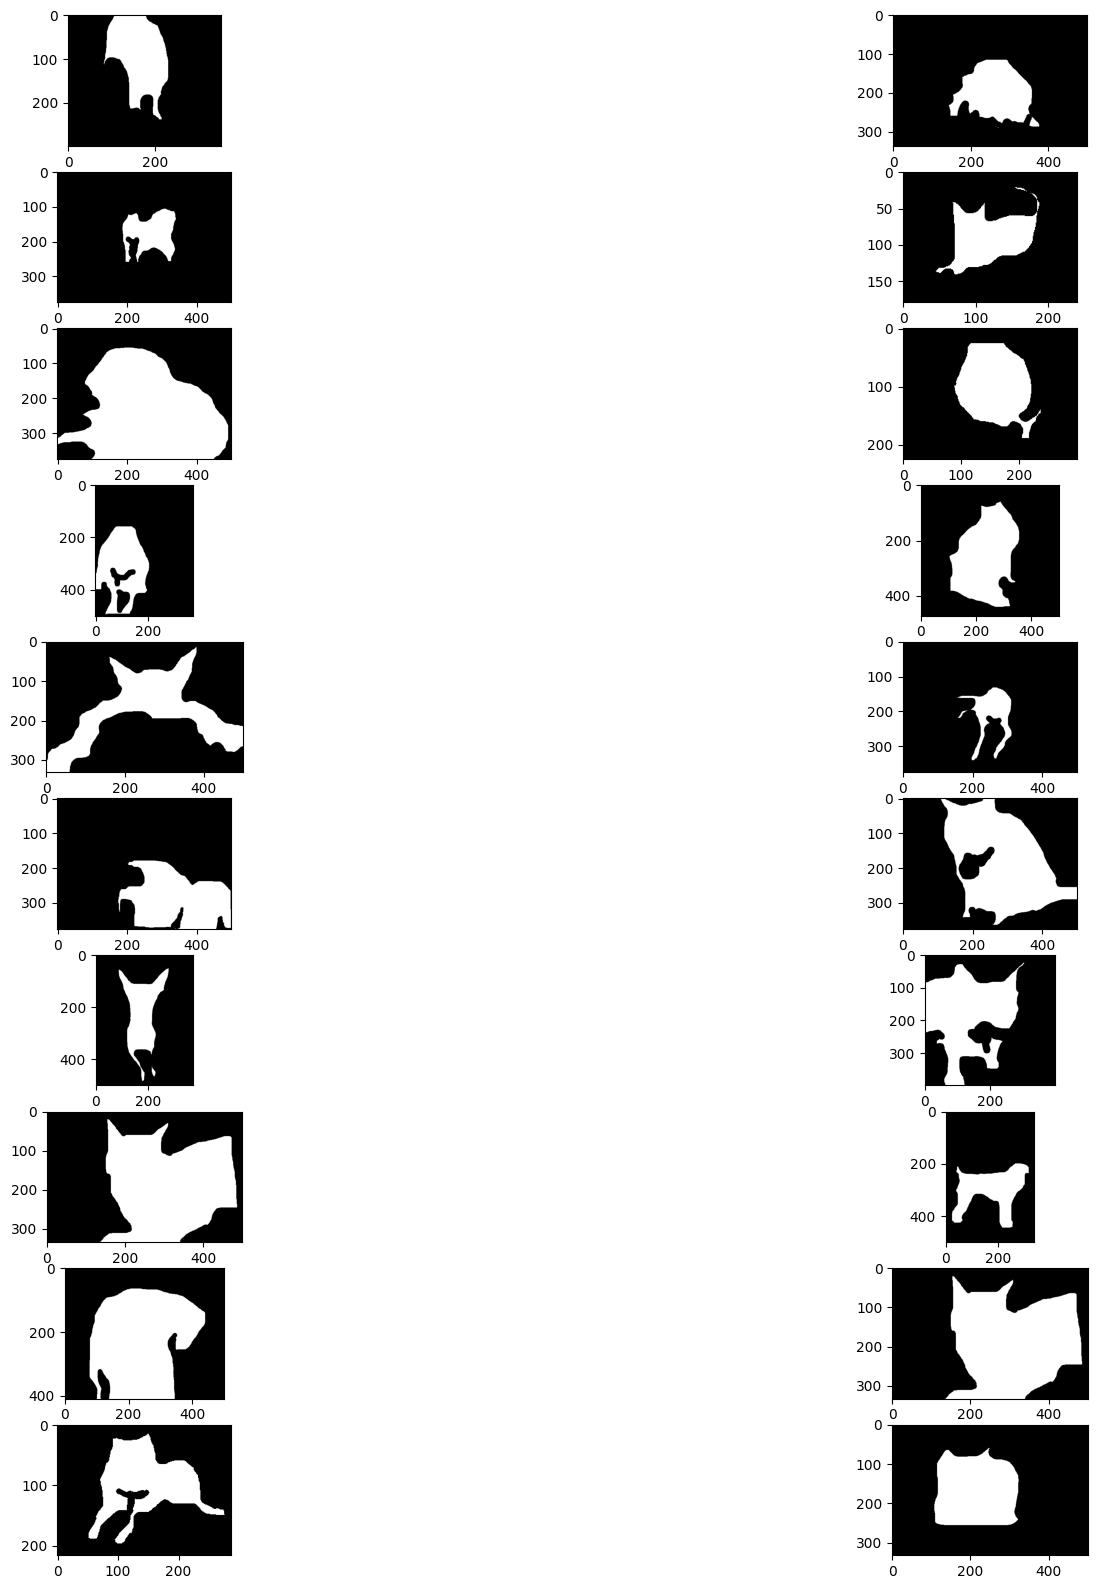

In [4]:
fig, axes = plt.subplots(10, 2, figsize=(20, 20))
axes = axes.flatten()
train_img_path  = os.path.join(path, 'val_imgs')
train_mask_path = os.path.join(path, 'val_masks')
for idx, file in enumerate(os.listdir(train_mask_path)):
    img = Image.open(os.path.join(train_mask_path, file)).convert('L')
    img= np.array(img)
    axes[idx].imshow(img, cmap='gray')
plt.show()

In [5]:
for file in os.listdir(os.path.join(path, "test_imgs")):
    img= Image.open(os.path.join(path, "test_imgs", file)).convert("RGB")
    img= np.array(img)
    print(img.shape)
    break

(500, 500, 3)


In [6]:
len(os.listdir(os.path.join(path, "val_imgs"))), len(os.listdir(os.path.join(path, "test_imgs")))

(20, 1000)

In [7]:
import random

def copy_paste(img1, mask1, img2, mask2):
    h, w = img1.shape[:2]
    x1, y1 = random.randint(0, w//2), random.randint(0, h//2)
    x2, y2 = random.randint(w//2, w), random.randint(h//2, h)
    img = img1.copy()
    mask = mask1.copy()
    img[y1:y2, x1:x2] = img2[y1:y2, x1:x2]
    mask[y1:y2, x1:x2] = mask2[y1:y2, x1:x2]
    return img, mask

def mosaic(imgs, masks):
    h, w = imgs[0].shape[:2]
    new_img = np.zeros((h*2, w*2, 3), dtype=imgs[0].dtype)
    new_mask = np.zeros((h*2, w*2), dtype=masks[0].dtype)
    new_img[:h, :w] = imgs[0]
    new_img[:h, w:] = imgs[1]
    new_img[h:, :w] = imgs[2]
    new_img[h:, w:] = imgs[3]
    new_mask[:h, :w] = masks[0]
    new_mask[:h, w:] = masks[1]
    new_mask[h:, :w] = masks[2]
    new_mask[h:, w:] = masks[3]
    return new_img, new_mask

In [11]:
import albumentations as A

augments = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, border_mode=0, p=0.5),
    A.Affine(
        scale=(0.85, 1.15),
        translate_percent=(-0.08, 0.08),
        rotate=(-15, 15),
        border_mode=0,
        p=0.5
    ),
    A.RandomResizedCrop(
        size=(512, 512),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1),
        p=0.5
    ),
    A.OneOf([
        A.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1
        ),
        A.RandomBrightnessContrast(),
        A.CLAHE(),
    ], p=0.5),
    A.CoarseDropout(
        num_holes_range=(2, 5),
        hole_height_range=(30, 80),
        hole_width_range=(30, 80),
        fill="random_uniform",
        p=0.3
    ),
    A.OneOf([
        A.GaussianBlur(),
        A.MotionBlur(),
        A.GaussNoise(),
    ], p=0.25),

], p=1.0)

out_path = "/kaggle/working"
out_img_path = os.path.join(out_path, "images")
out_mask_path = os.path.join(out_path, "masks")
#print(len(out_img_path))
os.makedirs(out_img_path, exist_ok = True)
os.makedirs(out_mask_path, exist_ok = True)
for idx, file in enumerate(os.listdir(os.path.join(path, "val_imgs"))):
    img = np.array(Image.open(os.path.join(path, "val_imgs", file)).convert("RGB"))
    mask_path = file.split(".")[0] + ".png"
    mask = Image.open(os.path.join(path, "val_masks", mask_path))
    mask = mask.resize((img.shape[1], img.shape[0]), Image.NEAREST)
    mask = np.array(mask)
    img_name = file.split(".")[0]
    for i in range(15):
        aug = augments(image=img, mask=mask)
        img_n = Image.fromarray(aug["image"])
        mask_n = Image.fromarray(aug["mask"])
        img_n.save(f"{out_img_path}/{img_name}_{i}.jpg")
        mask_n.save(f"{out_mask_path}/{img_name}_{i}.png")

print(len(os.listdir(out_img_path)))

22
300


In [12]:
len(os.listdir(os.path.join(path, "val_imgs")))

20

In [13]:
import random
class DF(Dataset):
    def __init__(self, path, processor, is_test=False):
        self.path = path
        self.processor = processor
        self.is_test = is_test
        self.folder = "test_imgs" if is_test else "images"
        self.imgs = os.listdir(os.path.join(self.path, self.folder))
    def __len__(self):
        return len(self.imgs)
    def load_sample(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.path, self.folder, img_name)
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = None
        if not self.is_test:
            mask_path = os.path.join(
                self.path,
                "masks",
                img_name.replace(".jpg", ".png")
            )
            mask = np.array(Image.open(mask_path))
        return image, mask, img_name
    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.path, self.folder, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.is_test:
            inputs = self.processor(images=image, return_tensors="pt")
            return {k: v.squeeze(0) for k, v in inputs.items()}, img_name
        image = np.array(image)
        mask_path = os.path.join(
            self.path,
            "masks",
            img_name.replace(".jpg", ".png")
        )
        mask = np.array(Image.open(mask_path))
        mask = mask.astype(np.int64)
        if random.random() < 0.4:
            i = random.randint(0, len(self.imgs) - 1)
            img2, mask2, _ = self.load_sample(i)
            mask2 = mask2.astype(np.int64)
            image, mask = copy_paste(image, mask, img2, mask2)
        elif random.random() < 0.2:
            idxs = random.sample(range(len(self.imgs)), 4)
            imgs, masks = [], []
            for i in idxs:
                img_i, mask_i, _ = self.load_sample(i)
                imgs.append(img_i)
                masks.append(mask_i.astype(np.int64))
            image, mask = mosaic(imgs, masks)
        inputs = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )
        return {k: v.squeeze(0) for k, v in inputs.items()}
from transformers import SegformerImageProcessor, SegformerModel, SegformerForSemanticSegmentation
processor = SegformerImageProcessor()
train_df = DF("/kaggle/working/", processor, is_test = False)
test_df = DF(path, processor, True)
train_dl = DataLoader(train_df, batch_size = 16, shuffle =True, num_workers= 4, pin_memory= True)
test_dl =DataLoader(test_df, batch_size =16, shuffle = False, num_workers =4, pin_memory = True)
for batch in train_dl:
    x = batch
    print(x.keys())
    break
for batch in test_dl:
    x = batch[0]
    print(x.keys())
    break

dict_keys(['pixel_values', 'labels'])
dict_keys(['pixel_values'])


In [14]:
#copied cm-ssl loss from google search ai
class CorrelationMaximizedStructuralSimilarityLoss(nn.Module):
    def __init__(self, kernel_size=11, sigma=1.5, reduction='mean'):
        super(CorrelationMaximizedStructuralSimilarityLoss, self).__init__()
        self.kernel_size = kernel_size
        self.sigma = sigma
        self.reduction = reduction

    def _get_gaussian_kernel(self, channels):
        # Create 1D Gaussian kernel
        coords = torch.arange(self.kernel_size, dtype=torch.float32)
        coords -= (self.kernel_size - 1) / 2.0
        g = torch.exp(-(coords**2) / (2 * self.sigma**2))
        g /= g.sum()
        
        # Reshape to 2D
        g_2d = g.unsqueeze(0) * g.unsqueeze(1)
        # Expand to match channels
        return g_2d.expand(channels, 1, self.kernel_size, self.kernel_size)

    def forward(self, pred, target):
        # Assumes inputs are in (B, C, H, W) format
        B, C, H, W = pred.shape
        
        # Keep channel dimensions by applying group convolution for local statistics
        kernel = self._get_gaussian_kernel(C).to(pred.device)
        
        # 1. Local Means ($\mu$)
        mu_x = F.conv2d(pred, kernel, groups=C, padding=self.kernel_size // 2)
        mu_y = F.conv2d(target, kernel, groups=C, padding=self.kernel_size // 2)

        # 2. Local Variances and Covariances ($\sigma_x^2$, $\sigma_y^2$, $\sigma_{xy}$)
        # Note: Valid unbiased variance requires a sum of weights, which simplifies in uniform Gaussian smoothing
        mu_x_sq = mu_x**2
        mu_y_sq = mu_y**2
        mu_xy = mu_x * mu_y

        sigma_x_sq = F.conv2d(pred**2, kernel, groups=C, padding=self.kernel_size // 2) - mu_x_sq
        sigma_y_sq = F.conv2d(target**2, kernel, groups=C, padding=self.kernel_size // 2) - mu_y_sq
        sigma_xy = F.conv2d(pred * target, kernel, groups=C, padding=self.kernel_size // 2) - mu_xy

        # 3. Correlation-Maximized Loss Calculation
        # Stabilizing constant to avoid division by zero
        C_N = 1e-4 * (1.0**2) 
        
        # The SSL formulation calculates structural similarity using linear correlation principles
        numerator = 2 * sigma_xy + C_N
        denominator = sigma_x_sq + sigma_y_sq + C_N
        
        # Calculate local structural similarity map
        ssl_map = numerator / denominator
        
        # Correlation Maximized Loss attempts to bring the value as close to 1 as possible
        loss = 1.0 - ssl_map

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


cm_ssl = CorrelationMaximizedStructuralSimilarityLoss()
bce = nn.BCEWithLogitsLoss()
def dice_loss(pred, target, eps=1e-7):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()
def loss_fn(pred, target):
    return 0.3*bce(pred, target) + 0.4*dice_loss(pred, target) + 0.3*cm_ssl(pred, target)


In [15]:
name = "nvidia/segformer-b0-finetuned-ade-512-512"
class MODEL(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = SegformerForSemanticSegmentation.from_pretrained(name, num_labels  =1, ignore_mismatched_sizes= True)
    def forward(self, x):
        return self.model(pixel_values = x,)

device = ("cuda" if torch.cuda.is_available() else "cpu")
model = MODEL().to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [16]:
for batch in train_dl:
        inputs = batch
        pixel_values, y = inputs["pixel_values"].to(device), inputs["labels"].to(device)
        print(pixel_values.shape)
        print(y.shape)
        with torch.no_grad():
            out = model(pixel_values).logits
        print(out.shape)
        break

torch.Size([16, 3, 512, 512])
torch.Size([16, 512, 512])
torch.Size([16, 1, 128, 128])


In [21]:
len(train_df)

200

In [18]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-5)

model = MODEL().to(device)
model = nn.DataParallel(model)

for e in range(20):
     model.train()
     t_loss = 0
     for batch in train_dl:
         pixel_values = batch["pixel_values"].to(device)
         y = batch["labels"].to(device).unsqueeze(1).float()
         y = (y > 0).float()
         opt.zero_grad()
         out = model(pixel_values).logits
         if out.shape[-2:] != y.shape[-2:]:
             out = F.interpolate(out, size=y.shape[-2:], mode="bilinear", align_corners=False)
         loss = loss_fn(out, y)
         loss.backward()
         opt.step()
         t_loss += loss.item()
     torch.cuda.empty_cache()
     print(f"Epoch {e}, loss: {t_loss/len(train_dl):.4f}")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 0, loss: 0.7445
Epoch 1, loss: 0.7421
Epoch 2, loss: 0.7406
Epoch 3, loss: 0.7440
Epoch 4, loss: 0.7421
Epoch 5, loss: 0.7423
Epoch 6, loss: 0.7419
Epoch 7, loss: 0.7411
Epoch 8, loss: 0.7412
Epoch 9, loss: 0.7427
Epoch 10, loss: 0.7414
Epoch 11, loss: 0.7401
Epoch 12, loss: 0.7431


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa8f3c66480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

KeyboardInterrupt: 

0it [00:00, ?it/s]

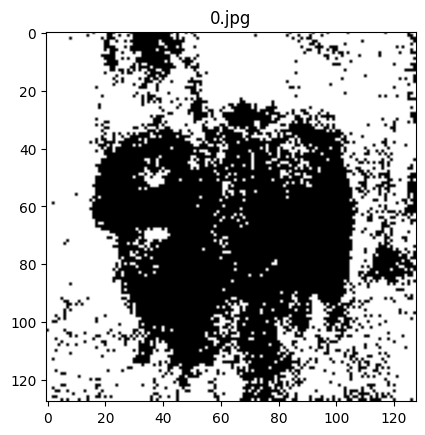

0it [00:00, ?it/s]

tensor(0, device='cuda:0', dtype=torch.int32) tensor(1, device='cuda:0', dtype=torch.int32)


In [25]:
from tqdm import tqdm
for idx, file in tqdm(enumerate(sorted(os.listdir(os.path.join(path, "test_imgs"))))):
    img = Image.open(os.path.join(path, "test_imgs", file)).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(inputs["pixel_values"]).logits
    out = torch.sigmoid(out)
    out = (out >0.5).int()
    mask = out.squeeze().cpu().numpy()
    plt.imshow(mask, cmap="gray")
    plt.title(file)
    plt.show()
    break

print(out.min(), out.max())

In [56]:
FOREGROUND_CLASSES = [12, 13]

In [27]:
test_preds = []
test_img_names = []

model.eval()

for idx, file in tqdm(enumerate(sorted(os.listdir(os.path.join(path, "test_imgs"))))):

    img = Image.open(os.path.join(path, "test_imgs", file)).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(inputs["pixel_values"]).logits   
    h, w = img.height, img.width
    if out.shape[-2:] != (h, w):
        out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)
    pred =  torch.sigmoid(out)
    pred = (pred >0.5).int()
    test_preds.append(pred.cpu().numpy())
    test_img_names.append(file)

1000it [00:44, 22.24it/s]


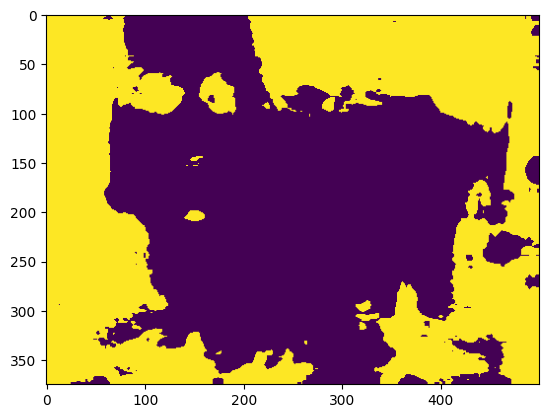

In [30]:
plt.imshow(np.squeeze(test_preds[0]))

In [31]:
import io
import base64
from io import BytesIO
def image_to_base64(image: Image.Image, fmt: str = "PNG") :
    buf = BytesIO()
    image.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode("utf-8")
ids = []
b64 = []
for img_name, seg_mask in zip(test_img_names, test_preds):
    ids.append(img_name[:-4]) 
    mask = Image.fromarray((np.squeeze(seg_mask) * 255).astype(np.uint8))
    b64.append(image_to_base64(mask.convert("L")))

In [32]:
sub = pd.DataFrame({
    "img_id": [int(i) for i in ids],
    "mask": b64
})

sub

,img_id,mask
0,0,iVBORw0KGgoAAAANSUhEUgAAAfQAAAF3CAAAAAB2meYgAA...
1,1,iVBORw0KGgoAAAANSUhEUgAAAfQAAAF3CAAAAAB2meYgAA...
2,10,iVBORw0KGgoAAAANSUhEUgAAAU0AAAH0CAAAAACcXiClAA...
3,100,iVBORw0KGgoAAAANSUhEUgAAASwAAAEBCAAAAADnJMdBAA...
4,101,iVBORw0KGgoAAAANSUhEUgAAAZAAAAEJCAAAAACfvS6bAA...
...,...,...
995,995,iVBORw0KGgoAAAANSUhEUgAAAXcAAAH0CAAAAADjjzJUAA...
996,996,iVBORw0KGgoAAAANSUhEUgAAAOcAAAEsCAAAAAAdx/s/AA...
997,997,iVBORw0KGgoAAAANSUhEUgAAAMgAAAEsCAAAAACjkaNiAA...
998,998,iVBORw0KGgoAAAANSUhEUgAAAfQAAAFNCAAAAADTeMLrAA...


In [33]:
sub.to_csv("seg_former3.csv",index = False)